In [30]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict

In [31]:
class BatsmanState(TypedDict):
    runs:int
    balls:int
    fours:int
    sixes:int

    sr:float
    bpb:float
    boundery_percentage:float
    summary:str

In [44]:
def cal_sr(state:BatsmanState):
    sr = round((state['runs']/state['balls']) * 100, 2)

    return {  'sr': sr} 



In [45]:
def cal_bpb(state:BatsmanState):
    bpb = state['balls']/(state['fours'] + state['sixes']) if state['runs'] > 0 else 0

    return { 'bpb': bpb }


In [46]:
def cal_boundery_percentage(state:BatsmanState)->BatsmanState:
    boundery_percentage = 100*(state['fours']*4 + state['sixes']*6)/state['balls'] if state['balls'] > 0 else 0

    return {'boundery_percentage': boundery_percentage }

In [47]:
def summary(state:BatsmanState)->BatsmanState:
    summary = f"""
    Runs: {state['runs']}
    Balls: {state['balls']}
    Fours: {state['fours']}
    Sixes: {state['sixes']}
    Strike Rate: {state['sr']}
    Balls per Boundary: {state['bpb']}
    Boundary Percentage: {state['boundery_percentage']}
    
"""
    
    return {    'summary': summary }

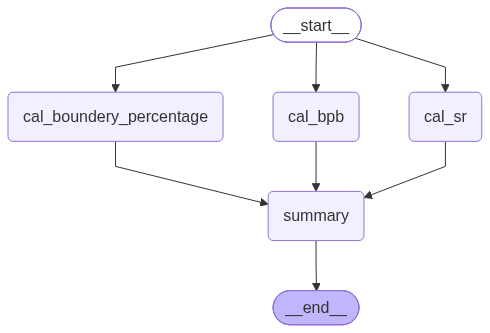

In [48]:
graph = StateGraph(BatsmanState)

graph.add_node('cal_sr',cal_sr)
graph.add_node('cal_bpb',cal_bpb)
graph.add_node('cal_boundery_percentage',cal_boundery_percentage)
graph.add_node('summary',summary)

## edges

graph.add_edge(START,'cal_sr')
graph.add_edge(START,'cal_bpb')
graph.add_edge(START,'cal_boundery_percentage')

graph.add_edge('cal_sr','summary')
graph.add_edge('cal_bpb','summary') 
graph.add_edge('cal_boundery_percentage','summary')

graph.add_edge('summary',END)

workflow = graph.compile()
workflow


In [49]:
initial_state ={
    'runs': 100,
    'balls': 60,
    'fours': 10,
    'sixes': 5
}
workflow.invoke(initial_state)

{'runs': 100,
 'balls': 60,
 'fours': 10,
 'sixes': 5,
 'sr': 166.67,
 'bpb': 4.0,
 'boundery_percentage': 116.66666666666667,
 'summary': '\n    Runs: 100\n    Balls: 60\n    Fours: 10\n    Sixes: 5\n    Strike Rate: 166.67\n    Balls per Boundary: 4.0\n    Boundary Percentage: 116.66666666666667\n    \n'}

: 